# Using Bifurcations to Switch Between Point Attractors and Limit Cycles

**Course project based on:**  
Farshad Khadivar, Ilaria Lauzana, and Aude Billard,  
*Learning Dynamical Systems with Bifurcations*, Robotics and Autonomous Systems.

## Project Motivation

In this project, I study how a single nonlinear dynamical system can generate two different types of robot motion: point-to-point motion and rhythmic motion. I chose this paper because it gives a practical robotics application of several concepts covered in class, especially equilibrium points, stability, phase portraits, limit cycles, bifurcations, and switched systems.

The main question I investigate is:

> **Can one dynamical system change from a stable point attractor to a stable limit cycle by varying only one interpretable parameter?**

This question is important in robotics because many tasks naturally combine both behaviors. For example, a robot may first move toward an object and then perform a repeated motion such as wiping or polishing. A simple approach would be to use one controller for reaching and another controller for rhythmic motion. However, switching between two separate dynamical systems can produce abrupt velocity changes and jerky motion.

The paper proposes a different idea: instead of switching between separate controllers, both behaviors are embedded inside one parameterized dynamical system. By changing a bifurcation-like parameter, the same system can smoothly transition between a point attractor and a limit cycle.

In my replication, I focus on the core nonlinear-dynamics mechanism and its robotic interpretation. I first analyze the simplified 2D system through stability analysis, phase portraits, parameter sweeps, and a comparison between hard switching and smooth parameter switching. Then, I connect the analysis to robotics by implementing a MuJoCo simulation study with the Franka Research 3 robot, where the dynamical system is used to generate reference end-effector motion.

## 1. Motivation

Robotic motion often contains two different behaviors:

- **Point-to-point motion:** reaching, moving to a target, pick-and-place.
- **Rhythmic motion:** wiping, polishing, walking, drumming.

A common approach is to model these with separate dynamical systems and switch between them online. The paper argues that hard switching can create discontinuities, jerky velocity profiles, and possible instability when the systems have different attractors. The proposed solution is to encode both behaviors in one parameterized dynamical system, so changing a parameter changes the behavior without replacing the controller.

### 1.1 Course Concepts Used in This Project

Before implementing the paper, I first identified the nonlinear dynamics concepts from class that appear in this work. The paper is useful for my project because it gives a robotics application of several core ideas:

1. Equilibrium point: when the target radius is zero, the system behaves like a stable point attractor.
2. Stability: the radial error decays exponentially, so I can directly connect the model to asymptotic stability.
3. Phase portrait: by plotting trajectories from different initial conditions, I can visualize the vector field and attraction behavior.
4. Limit cycle: when the target radius is nonzero, the trajectory does not converge to a point; it converges to a closed orbit.
5. Bifurcation: changing the radius parameter changes the qualitative long-term behavior of the system.
6. Switched systems: the paper motivates why switching between different dynamical systems can create jerky transients.
7. System identification: the learning part of the paper estimates model parameters from demonstration data.

Therefore, I am not treating the paper only as a robotics-control paper. I am using it as a case study to understand how concepts from nonlinear dynamical systems can be used to generate robot motion.

## 2. Classical Hopf Bifurcation and Paper Formulation

### 2.1 Connection to the Classical Hopf Bifurcation

A standard supercritical Hopf bifurcation can be written in polar coordinates as

$$
\dot{r} = \mu r - r^3, \qquad \dot{\theta}=\omega.
$$

For this classical Hopf normal form:

- If `mu < 0`, the origin `r=0` is stable.
- If `mu > 0`, a stable limit cycle appears at `r = sqrt(mu)`.

This is the class concept of a **Hopf bifurcation**: changing a bifurcation parameter changes the qualitative long-term behavior from an equilibrium to a periodic orbit.

The paper does not directly use the classical Hopf normal form. Instead, it designs a Hopf-inspired system where the target radius `rho0` directly controls whether the system behaves as a point attractor or a limit cycle. This makes the controller easier to modulate in robotics, because the cycle radius, center, orientation, and rotation speed can be changed explicitly.

## 3. Mathematical Model Used in This Project

The simplified 2D model used in this notebook follows the paper's polar-coordinate form:

$$
\dot{\rho} = -\sqrt{M}(\rho - \rho_0),
\qquad
\dot{\theta} = R e^{-M^2(\rho - \rho_0)^2}.
$$

Here:

- `rho` is distance from the attractor center.
- `theta` is the angular coordinate.
- `rho0` is the target radius and acts like a bifurcation-like parameter.
- `M > 0` controls radial convergence.
- `R` controls angular speed and rotation direction.

Two behaviors come from the same equation:

- `rho0 = 0`: trajectories converge to a stable point equilibrium.
- `rho0 > 0`: trajectories converge to a stable limit cycle of radius `rho0`.

This is Hopf-inspired rather than an exact classical Hopf normal form. The paper deliberately reparameterizes the system so the limit-cycle radius is directly controllable.

## 4. Cartesian Implementation of the 2D DS

The function below converts Cartesian coordinates to polar coordinates around a chosen center, applies the radial and angular dynamics, and converts the velocity back to Cartesian form. This produces a vector field that can represent either a stable equilibrium or a stable periodic orbit without changing the structure of the equation.

In [34]:
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("ggplot")
np.set_printoptions(precision=3, suppress=True)


def ds_2d(x, rho0=1.0, M=3.0, R=2.0, center=(0.0, 0.0)):
    """2D Hopf-inspired dynamical system from the paper."""
    x = np.asarray(x, dtype=float)
    c = np.asarray(center, dtype=float)
    y = x - c

    rho = np.linalg.norm(y)
    if rho < 1e-9:
        radial = np.array([1.0, 0.0])
    else:
        radial = y / rho

    tangent = np.array([-radial[1], radial[0]])
    rho_dot = -np.sqrt(M) * (rho - rho0)
    theta_dot = R * np.exp(-(M**2) * (rho - rho0) ** 2)

    return rho_dot * radial + rho * theta_dot * tangent


def simulate_2d(x0, params_fn, dt=0.01, steps=3000):
    """Forward-Euler simulation with possibly time-varying 
       parameters."""
    xs = np.zeros((steps + 1, 2))
    vs = np.zeros((steps, 2))
    xs[0] = np.asarray(x0, dtype=float)
    for k in range(steps):
        params = params_fn(k * dt)
        vs[k] = ds_2d(xs[k], **params)
        xs[k + 1] = xs[k] + dt * vs[k]
    return xs, vs


def constant_params(rho0, M=3.0, R=4.0, center=(0.0, 0.0)):
    return lambda t: {"rho0": rho0, "M": M, "R": R, "center": 
                      center}

## 5. Equilibrium and Stability Analysis

The radial dynamics are

$$
\dot{\rho} = -\sqrt{M}(\rho-\rho_0).
$$

Define the radial error

$$
e = \rho-\rho_0.
$$

Then

$$
\dot{e} = -\sqrt{M}e,
\qquad
e(t)=e(0)e^{-\sqrt{M}t}.
$$

So for `M > 0`, radial error decays exponentially.

**Case A: `rho0 = 0`.** Then `rho(t) -> 0`, so the system converges to the origin. This is the stable equilibrium point case.

**Case B: `rho0 > 0`.** Then `rho(t) -> rho0`. The state does not converge to one point; it converges to the circle

$$
x^2+y^2=\rho_0^2.
$$

This circle is a stable limit cycle, or more generally a stable invariant set.

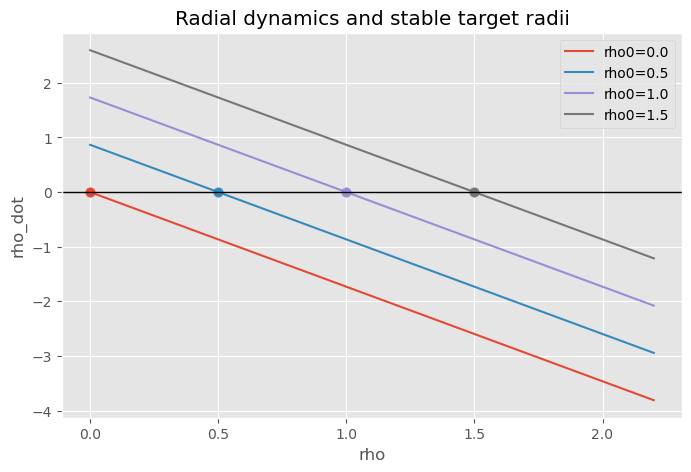

In [35]:
rho0_values = [0.0, 0.5, 1.0, 1.5]
rho = np.linspace(0, 2.2, 300)
M = 3.0

plt.figure(figsize=(8, 5))
for rho0 in rho0_values:
    rho_dot = -np.sqrt(M) * (rho - rho0)
    plt.plot(rho, rho_dot, label=f"rho0={rho0}")
    plt.scatter([rho0], [0], s=45)

plt.axhline(0, color="black", lw=1)
plt.xlabel("rho")
plt.ylabel("rho_dot")
plt.title("Radial dynamics and stable target radii")
plt.legend()
plt.show()

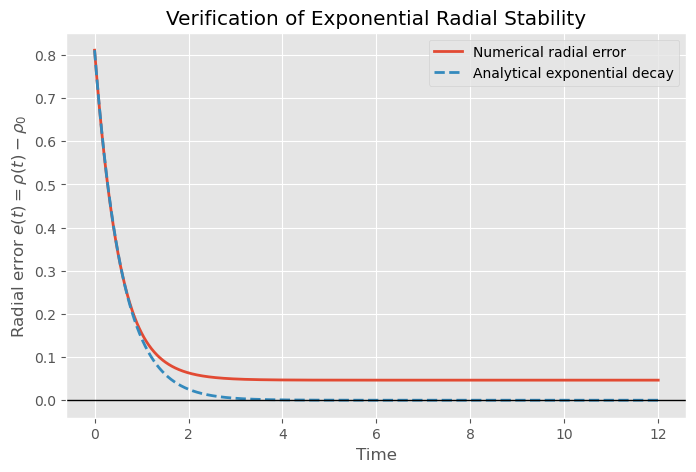

In [36]:
# Stability verification: numerical radial error vs analytical exponential decay

rho0 = 1.0
M = 3.0
R = 4.0
dt = 0.01
steps = 1200

x0 = (1.8, 0.2)
xs, _ = simulate_2d(x0, constant_params(rho0=rho0, M=M, R=R), dt=dt, steps=steps)

time = np.arange(steps + 1) * dt
rho = np.linalg.norm(xs, axis=1)
e_num = rho - rho0

e0 = e_num[0]
e_analytical = e0 * np.exp(-np.sqrt(M) * time)

plt.figure(figsize=(8, 5))
plt.plot(time, e_num, lw=2, label="Numerical radial error")
plt.plot(time, e_analytical, "--", lw=2, label="Analytical exponential decay")
plt.axhline(0, color="black", lw=1)
plt.xlabel("Time")
plt.ylabel(r"Radial error $e(t)=\rho(t)-\rho_0$")
plt.title("Verification of Exponential Radial Stability")
plt.legend()
plt.grid(True)
plt.show()

## 6. Phase Portraits: Point Attractor vs. Limit Cycle

The only parameter changed in the next experiment is `rho0`.

- `rho0 = 0`: the radius decays to zero, so the state converges to the center.
- `rho0 = 1`: the radius converges to one, so the trajectory approaches a closed orbit.

This directly connects to the class concepts of phase portraits, equilibria, and stable limit cycles.

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


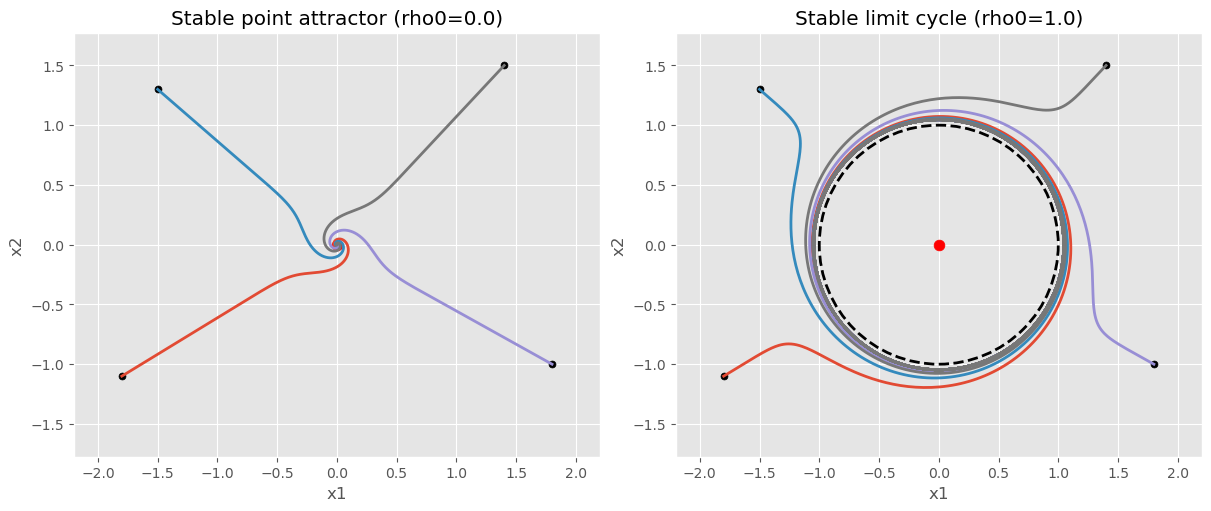

In [37]:
initial_conditions = [(-1.8, -1.1), (-1.5, 1.3), (1.8, -1.0), (1.4, 1.5)]

fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)
cases = [(0.0, "Stable point attractor"), (1.0, "Stable limit cycle")]

for ax, (rho0, title) in zip(axes, cases):
    for x0 in initial_conditions:
        xs, _ = simulate_2d(x0, constant_params(rho0=rho0), steps=2500)
        ax.plot(xs[:, 0], xs[:, 1], lw=2)
        ax.scatter(xs[0, 0], xs[0, 1], c="black", s=25)
    if rho0 > 0:
        ax.add_patch(plt.Circle((0, 0), rho0, fill=False, color="black", ls="--", lw=2))
    ax.scatter(0, 0, c="red", s=60, label="center")
    ax.set_title(title + f" (rho0={rho0})")
    ax.set_xlabel("x1")
    ax.set_ylabel("x2")
    ax.axis("equal")
    ax.set_xlim(-2.2, 2.2)
    ax.set_ylim(-2.2, 2.2)

plt.show()

## 7. Bifurcation-Like Parameter Sweep

A bifurcation diagram summarizes how stable long-term behavior changes with a parameter. In this Hopf-inspired system, the stable radial set is

$$
\rho^*=\rho_0.
$$

So the attracting set is a point when `rho0 = 0`, and a circle when `rho0 > 0`. The plot below is simple, but conceptually it plays the role of a bifurcation diagram: varying `rho0` changes the qualitative nature of the phase portrait.

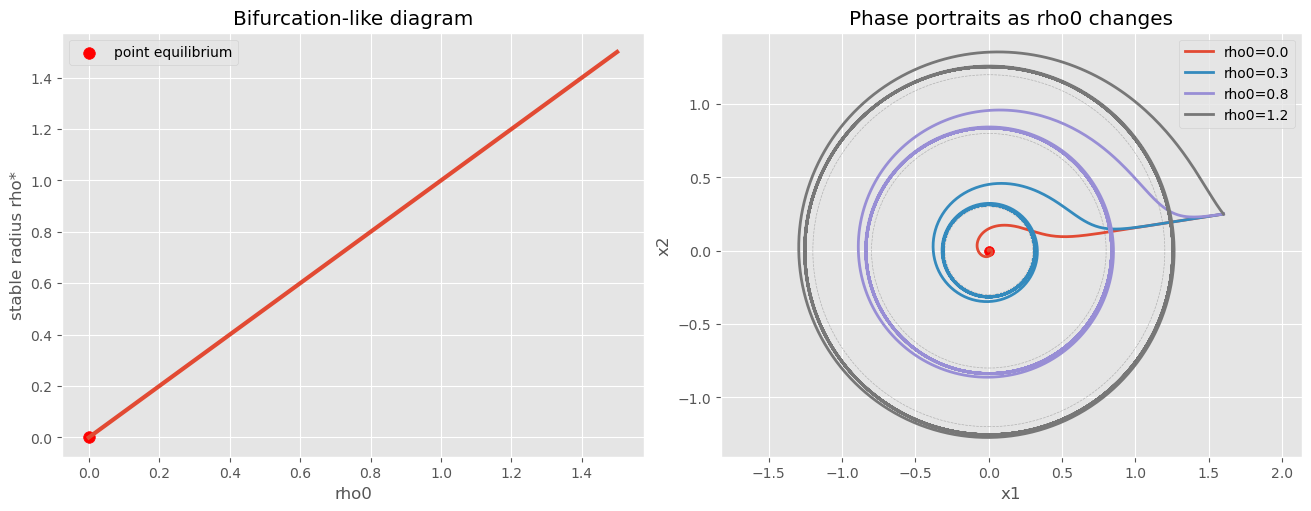

In [38]:
rho0_grid = np.linspace(0, 1.5, 100)
stable_radius = rho0_grid

fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)
axes[0].plot(rho0_grid, stable_radius, lw=3)
axes[0].scatter([0], [0], c="red", s=70, label="point equilibrium")
axes[0].set_xlabel("rho0")
axes[0].set_ylabel("stable radius rho*")
axes[0].set_title("Bifurcation-like diagram")
axes[0].legend()

for rho0 in [0.0, 0.3, 0.8, 1.2]:
    xs, _ = simulate_2d((1.6, 0.25), constant_params(rho0=rho0), steps=1800)
    axes[1].plot(xs[:, 0], xs[:, 1], lw=2, label=f"rho0={rho0}")
    if rho0 > 0:
        axes[1].add_patch(plt.Circle((0, 0), rho0, fill=False, color="gray", ls="--", alpha=0.5))

axes[1].scatter(0, 0, c="red", s=50)
axes[1].axis("equal")
axes[1].set_title("Phase portraits as rho0 changes")
axes[1].set_xlabel("x1")
axes[1].set_ylabel("x2")
axes[1].legend()
plt.show()

## 8. Effect of Parameters `M`, `R`, and `rho0`

The paper emphasizes interpretable parameters. In this implementation:

- Increasing `rho0` increases the final orbit radius.
- Increasing `M` increases radial convergence speed.
- Changing the sign of `R` changes rotation direction.

This is important for robotics because the same learned DS can be reused while the user changes speed, amplitude, center, and direction.

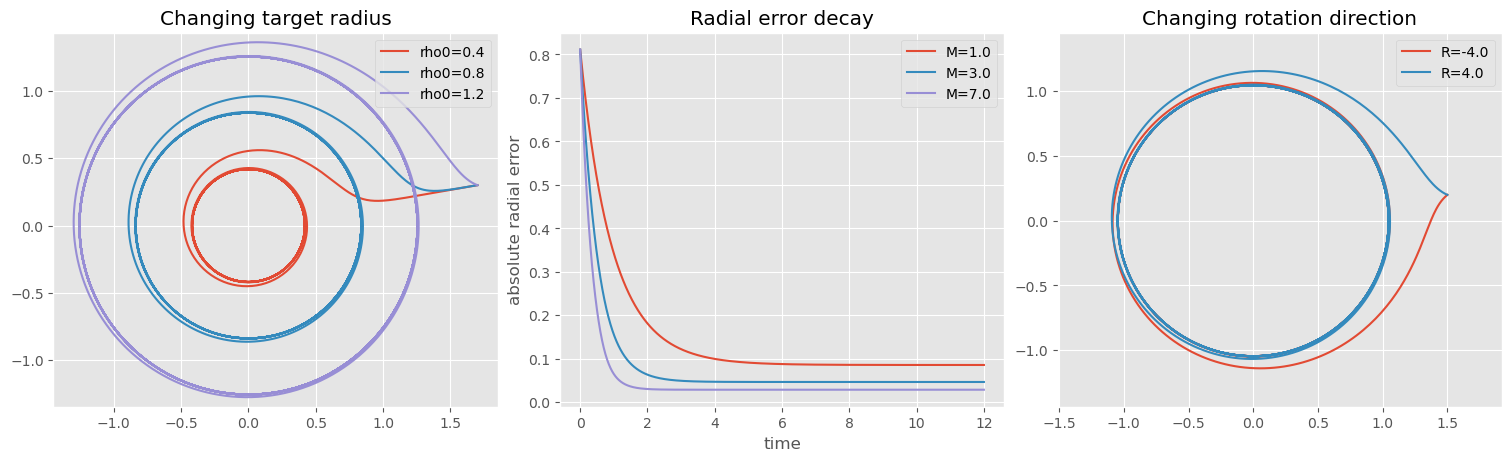

In [39]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), constrained_layout=True)

for rho0 in [0.4, 0.8, 1.2]:
    xs, _ = simulate_2d((1.7, 0.3), constant_params(rho0=rho0, M=3.0, R=4.0), steps=1800)
    axes[0].plot(xs[:, 0], xs[:, 1], label=f"rho0={rho0}")
axes[0].axis("equal")
axes[0].set_title("Changing target radius")
axes[0].legend()

for M_val in [1.0, 3.0, 7.0]:
    xs, _ = simulate_2d((1.8, 0.2), constant_params(rho0=1.0, M=M_val, R=4.0), steps=1200)
    radius_error = np.linalg.norm(xs, axis=1) - 1.0
    axes[1].plot(np.arange(len(xs)) * 0.01, np.abs(radius_error), label=f"M={M_val}")
axes[1].set_title("Radial error decay")
axes[1].set_xlabel("time")
axes[1].set_ylabel("absolute radial error")
axes[1].legend()

for R_val in [-4.0, 4.0]:
    xs, _ = simulate_2d((1.5, 0.2), constant_params(rho0=1.0, M=3.0, R=R_val), steps=1000)
    axes[2].plot(xs[:, 0], xs[:, 1], label=f"R={R_val}")
axes[2].axis("equal")
axes[2].set_title("Changing rotation direction")
axes[2].legend()

plt.show()

## 9. Smooth Parameter Switching vs. Hard Switching

The paper's practical motivation is that switching between separate DSs can create abrupt transients. In a switched system, the vector field can change discontinuously at the switching time.

Here we compare two cases:

- **Hard switching:** use a linear reaching controller, then suddenly switch to the limit-cycle DS.
- **Smooth parameter switching:** keep the same DS structure and smoothly ramp `rho0` from 0 to 1.

This connects directly to switched systems, discontinuity in vector fields, smooth transitions, and robustness.

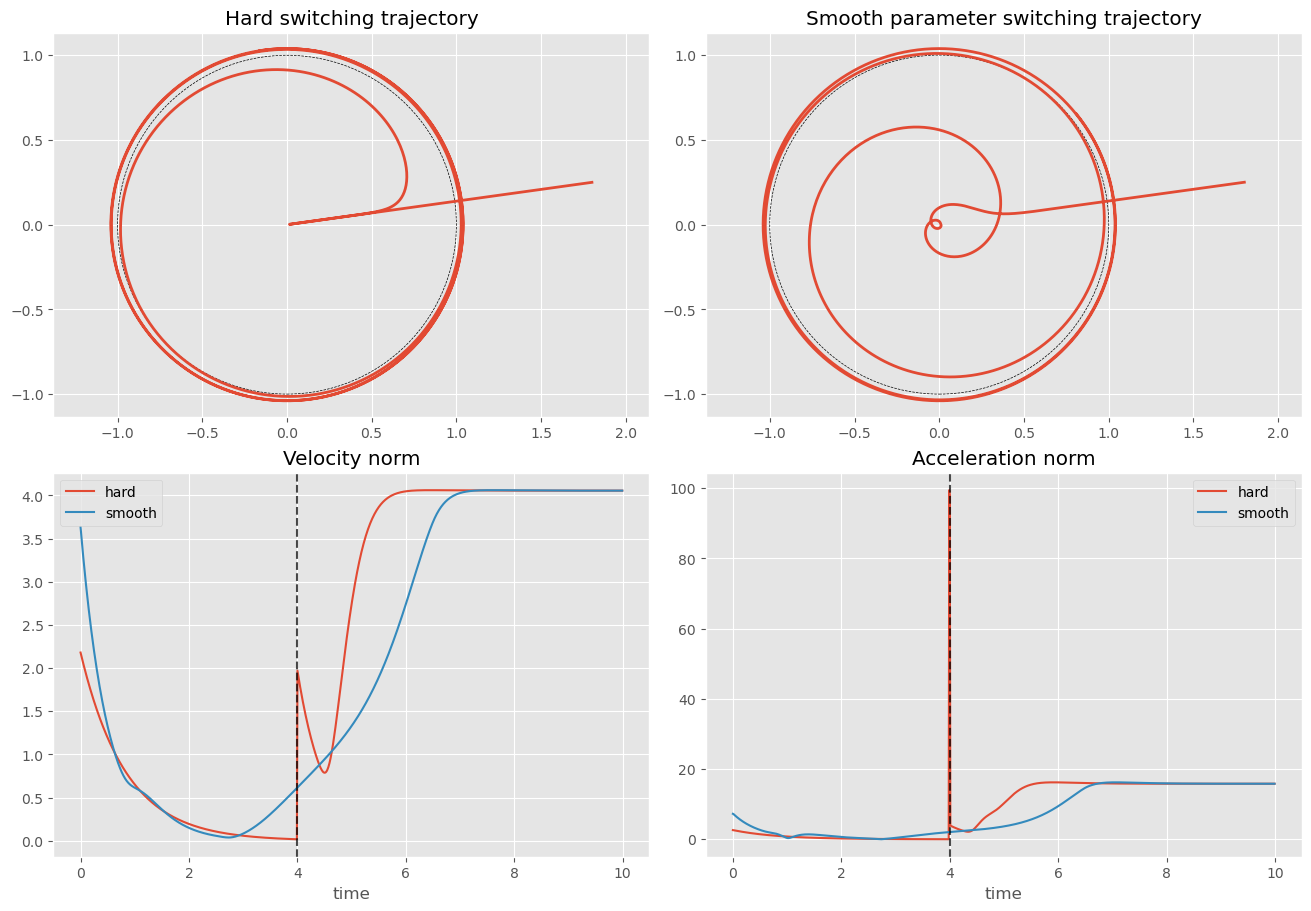

In [40]:
def linear_reach(x, goal=(0.0, 0.0), k=2.0):
    return -k * (np.asarray(x) - np.asarray(goal))


def smoothstep(s):
    s = np.clip(s, 0.0, 1.0)
    return s * s * (3.0 - 2.0 * s)


def simulate_hard_switch(x0, switch_time=4.0, dt=0.01, steps=1000):
    xs = np.zeros((steps + 1, 2))
    vs = np.zeros((steps, 2))
    xs[0] = np.asarray(x0, dtype=float)
    for k in range(steps):
        t = k * dt
        if t < switch_time:
            vs[k] = linear_reach(xs[k], goal=(0.0, 0.0), k=1.2)
        else:
            vs[k] = ds_2d(xs[k], rho0=1.0, M=4.0, R=4.0)
        xs[k + 1] = xs[k] + dt * vs[k]
    return xs, vs


def smooth_switch_params(t):
    ramp = smoothstep((t - 2.5) / 4.0)
    return {"rho0": ramp, "M": 4.0, "R": 4.0, "center": (0.0, 0.0)}


dt = 0.01
steps = 1000
x0 = (1.8, 0.25)
hard_xs, hard_vs = simulate_hard_switch(x0, dt=dt, steps=steps)
smooth_xs, smooth_vs = simulate_2d(x0, smooth_switch_params, dt=dt, steps=steps)
time = np.arange(steps) * dt

hard_acc = np.gradient(hard_vs, dt, axis=0)
smooth_acc = np.gradient(smooth_vs, dt, axis=0)

fig, axes = plt.subplots(2, 2, figsize=(13, 9), constrained_layout=True)

axes[0, 0].plot(hard_xs[:, 0], hard_xs[:, 1], lw=2)
axes[0, 0].add_patch(plt.Circle((0, 0), 1.0, fill=False, color="black", ls="--"))
axes[0, 0].set_title("Hard switching trajectory")
axes[0, 0].axis("equal")

axes[0, 1].plot(smooth_xs[:, 0], smooth_xs[:, 1], lw=2)
axes[0, 1].add_patch(plt.Circle((0, 0), 1.0, fill=False, color="black", ls="--"))
axes[0, 1].set_title("Smooth parameter switching trajectory")
axes[0, 1].axis("equal")

axes[1, 0].plot(time, np.linalg.norm(hard_vs, axis=1), label="hard")
axes[1, 0].plot(time, np.linalg.norm(smooth_vs, axis=1), label="smooth")
axes[1, 0].axvline(4.0, color="black", ls="--", alpha=0.7)
axes[1, 0].set_title("Velocity norm")
axes[1, 0].set_xlabel("time")
axes[1, 0].legend()

axes[1, 1].plot(time, np.linalg.norm(hard_acc, axis=1), label="hard")
axes[1, 1].plot(time, np.linalg.norm(smooth_acc, axis=1), label="smooth")
axes[1, 1].axvline(4.0, color="black", ls="--", alpha=0.7)
axes[1, 1].set_title("Acceleration norm")
axes[1, 1].set_xlabel("time")
axes[1, 1].legend()

plt.show()

In the hard-switching case, the vector field changes discontinuously at the switching time. This can create sharp changes in velocity and acceleration. In the parameter-varying case, the same dynamical-system structure is retained and only `rho0` changes smoothly. This mirrors the paper's robotic wiping experiment, where transitions inside one learned DS are smoother than switching between separate controllers.

## 10. Extension to 3D Planar Limit Cycles

The paper extends the idea to 3D using spherical-coordinate reasoning:

$$
\dot{\rho} = -\sqrt{M}(\rho - \rho_0),
\qquad
\dot{\phi} = -\sqrt{M}\phi,
\qquad
\dot{\theta} = R e^{-M^2(\rho - \rho_0)^2}.
$$

The elevation angle decays, so the motion settles onto a plane while the radial dynamics create either a point attractor or a planar limit cycle.

The simulation below is a simplified 3D demonstration of planar limit-cycle convergence. The full paper uses spherical-coordinate reasoning and PCA to orient the cycle plane in 3D.

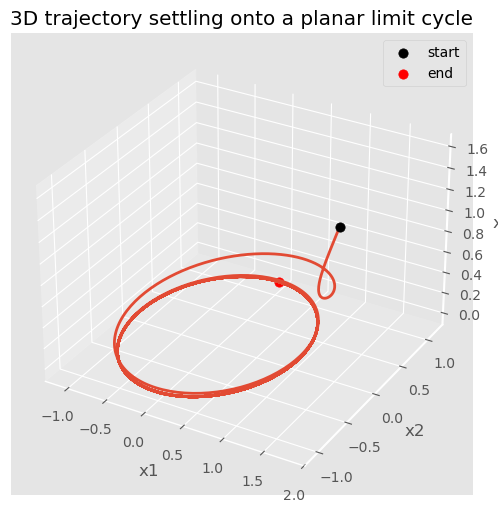

In [41]:
def simulate_3d(x0, rho0=1.0, M=3.0, R=4.0, dt=0.01, steps=3000):
    xs = np.zeros((steps + 1, 3))
    xs[0] = np.asarray(x0, dtype=float)
    sqrt_M = np.sqrt(M)

    for k in range(steps):
        x, y, z = xs[k]
        rho_xy = np.hypot(x, y)

        if rho_xy < 1e-9:
            radial_xy = np.array([1.0, 0.0])
        else:
            radial_xy = np.array([x, y]) / rho_xy

        tangent_xy = np.array([-radial_xy[1], radial_xy[0]])
        rho_dot = -sqrt_M * (rho_xy - rho0)
        theta_dot = R * np.exp(-(M**2) * (rho_xy - rho0) ** 2)
        xy_dot = rho_dot * radial_xy + rho_xy * theta_dot * tangent_xy
        z_dot = -sqrt_M * z

        xs[k + 1] = xs[k] + dt * np.array([xy_dot[0], xy_dot[1], z_dot])

    return xs


xs3 = simulate_3d((1.8, -0.4, 1.6), rho0=1.0)

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")
ax.plot(xs3[:, 0], xs3[:, 1], xs3[:, 2], lw=2)
ax.scatter(xs3[0, 0], xs3[0, 1], xs3[0, 2], c="black", s=45, label="start")
ax.scatter(xs3[-1, 0], xs3[-1, 1], xs3[-1, 2], c="red", s=45, label="end")
ax.set_title("3D trajectory settling onto a planar limit cycle")
ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.set_zlabel("x3")
ax.legend()
plt.show()

## 11. Learning from Demonstration: Parameter Estimation

The paper learns DS parameters from demonstrated robot trajectories. This section implements a small synthetic version of that idea.

We generate a noisy demonstration using known parameters, estimate `rho0`, `M`, and `R`, then reproduce the motion with the learned parameters. This connects the paper to least squares, system identification, model fitting, and vector-field learning.

Parameter      True      Learned
rho0         1.000     1.047
M            3.000     3.739
R            4.000     3.921


AttributeError: module 'matplotlib.pyplot' has no attribute 'add_artist'

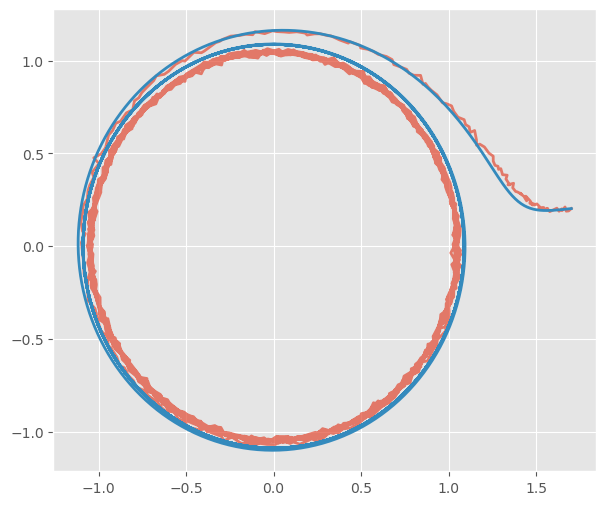

In [42]:
rng = np.random.default_rng(7)
true_params = {"rho0": 1.0, "M": 3.0, "R": 4.0, "center": (0.0, 0.0)}
demo_clean, _ = simulate_2d((1.7, 0.2), constant_params(**true_params), dt=0.01, steps=1800)
demo = demo_clean + rng.normal(scale=0.01, size=demo_clean.shape)

dt = 0.01
rho_data = np.linalg.norm(demo, axis=1)
theta_data = np.unwrap(np.arctan2(demo[:, 1], demo[:, 0]))
rho_dot_data = np.gradient(rho_data, dt)
theta_dot_data = np.gradient(theta_data, dt)

# Fit rho_dot = -a*rho + a*rho0 using least squares.
# Then sqrt(M)=a and rho0=intercept/a.
A = np.column_stack([rho_data, np.ones_like(rho_data)])
slope, intercept = np.linalg.lstsq(A, rho_dot_data, rcond=None)[0]
a_hat = max(-slope, 1e-9)
rho0_hat = intercept / a_hat
M_hat = a_hat**2

# Fit theta_dot = R * exp(-M^2*(rho-rho0)^2) using one-parameter least squares.
basis = np.exp(-(M_hat**2) * (rho_data - rho0_hat) ** 2)
R_hat = np.dot(basis, theta_dot_data) / np.dot(basis, basis)

learned_params = {"rho0": float(rho0_hat), "M": float(M_hat), "R": float(R_hat), "center": (0.0, 0.0)}
repro, _ = simulate_2d(demo[0], constant_params(**learned_params), dt=0.01, steps=1800)

print("Parameter      True      Learned")
print(f"rho0       {true_params['rho0']:7.3f}   {learned_params['rho0']:7.3f}")
print(f"M          {true_params['M']:7.3f}   {learned_params['M']:7.3f}")
print(f"R          {true_params['R']:7.3f}   {learned_params['R']:7.3f}")

plt.figure(figsize=(7, 6))
plt.plot(demo[:, 0], demo[:, 1], lw=2, alpha=0.7, label="noisy demonstration")
plt.plot(repro[:, 0], repro[:, 1], lw=2, label="reproduction from learned parameters")
plt.add_artist(plt.Circle((0, 0), true_params["rho0"], fill=False, color="black", ls="--"))
plt.axis("equal")
plt.title("Synthetic learning-from-demonstration experiment")
plt.xlabel("x1")
plt.ylabel("x2")
plt.legend()
plt.show()

This synthetic experiment is much simpler than the full paper, but it captures the key system-identification idea: estimate parameters of a dynamical system from observed motion data. The paper further uses PCA/Gaussian modeling to estimate the plane and center of demonstrated cycles, and uses diffeomorphism/GMR ideas to represent nonlinear limit-cycle shapes.

## 12. Connection to Course Concepts

| Course concept | Where it appears in this project | Evidence from simulation |
| --- | --- | --- |
| Equilibrium point | `rho0 = 0` case | trajectories converge to origin |
| Stable limit cycle | `rho0 > 0` case | trajectories converge to a circle |
| Hopf bifurcation | transition from point attractor to periodic orbit | parameter sweep over `rho0` |
| Phase portrait | point-attractor and limit-cycle plots | trajectories show flow toward point/cycle |
| Stability | radial error equation | `e(t)=e(0)e^{-sqrt(M)t}` |
| Invariant set | circle `x^2+y^2=rho0^2` | radius converges while angle keeps evolving |
| System identification | learning `rho0`, `M`, `R` | least-squares fit from synthetic data |
| Switched systems | hard switching comparison | velocity/acceleration jump under hard switch |
| Robotics application | reaching plus wiping-like motion | same DS generates discrete and rhythmic behavior |

## 13. Limitations

The quality of learned dynamics depends on the clarity and consistency of demonstrations. The simplified 3D implementation here only shows convergence to a planar limit cycle; the full paper estimates the motion plane and orientation more carefully. More complex non-circular cycles require an additional mapping, such as the diffeomorphic transformation described in the paper.

A useful future extension would be to compare this model against Dynamic Movement Primitives or to implement the paper's nonlinear limit-cycle learning step.

## 14. Conclusion

Khadivar, Lauzana, and Billard propose a Hopf-inspired dynamical-system framework that unifies point-to-point and rhythmic robot motions. By changing a small number of interpretable parameters, the same system can move between a stable equilibrium and a stable limit cycle. The simulations in this notebook reproduce the central mechanism, analyze its stability, visualize its bifurcation-like parameter sweep, compare smooth parameter modulation against hard switching, and show a small parameter-learning experiment from synthetic demonstration data.